# 77 — X-update fix parity rerun

This notebook re-runs the same-input persistent-tracker comparison after patching the 2-state Kalman x update to use the current frame's KLT x measurement instead of the initial frame's measurement.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
VIDEO = ROOT / 'data' / 'raw' / 'UltraTimTrack_test.mp4'
ROI_PATH = ROOT / 'data' / 'rois' / 'UltraTimTrack_test_rois.json'
MATLAB_RESULT = ROOT / 'data' / 'matlab' / 'slow_low_01_DOWN_tracked_Q=001.mat'
PREVIOUS_UPDATED = ROOT / 'results' / 'notebook75_persistent_tracker_matlab_python' / 'python_updated_exact_same_inputs' / VIDEO.stem / f'{VIDEO.stem}_strict_results.npz'
RUN_ROOT = ROOT / 'results' / 'notebook77_x_update_fix_parity' / 'python_x_update_fix_same_inputs'
RUN_DIR = RUN_ROOT / VIDEO.stem
UPDATED_NPZ = RUN_DIR / f'{VIDEO.stem}_strict_results.npz'
UPDATED_METADATA = RUN_DIR / f'{VIDEO.stem}_strict_metadata.json'
OUT = ROOT / 'results' / 'notebook77_x_update_fix_parity'
UTT_EXPORT = next((path for path in [
    ROOT / 'data' / 'matlab' / 'UTT_numeric_export.mat',
    Path('/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat'),
] if path.exists()), None)

for required in [VIDEO, ROI_PATH, MATLAB_RESULT, PREVIOUS_UPDATED]:
    assert required.exists(), required
assert UTT_EXPORT is not None
OUT.mkdir(parents=True, exist_ok=True)

print('Video:', VIDEO)
print('ROI:', ROI_PATH, json.loads(ROI_PATH.read_text()))
print('MATLAB result:', MATLAB_RESULT)
print('Previous updated run:', PREVIOUS_UPDATED)
print('New run root:', RUN_ROOT)

Video: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4
ROI: /Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json {'superficial': [20, 18, 685, 54], 'deep': [16, 302, 689, 76], 'fascicle': [23, 78, 679, 218]}
MATLAB result: /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat
Previous updated run: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook75_persistent_tracker_matlab_python/python_updated_exact_same_inputs/UltraTimTrack_test/UltraTimTrack_test_strict_results.npz
New run root: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook77_x_update_fix_parity/python_x_update_fix_same_inputs


## Fresh rerun with the x-update patch

This cell intentionally re-runs the full strict pipeline on the same video and ROI so the parity comparison reflects the patched Kalman x update.

In [2]:
runner_command = [
    sys.executable,
    str(ROOT / 'scripts' / 'run_ultratimtrack_adaptive_confidence.py'),
    str(VIDEO),
    '--roi-path', str(ROI_PATH),
    '--utt-export', str(UTT_EXPORT),
    '--results-dir', str(RUN_ROOT),
    '--seed-frames', '11',
    '--apo-maxangle', '10',
    '--candidate-persistence',
    '--apo-gating',
    '--kalman-mode', 'adaptive-anisotropic',
    '--compare-to-fixed-kalman',
    '--save-confidence-plots',
    '--no-annotated-video',
    '--save-overlays', '2',
    '--no-time-series-plot',
    '--progress-every', '100',
]

env = dict(os.environ)
env.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
subprocess.run(runner_command, cwd=ROOT, env=env, check=True)
assert UPDATED_NPZ.exists(), UPDATED_NPZ

Loading ROIs: /Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json

Running TimTrack image stream...
TimTrack image geofeatures processed 100
TimTrack image geofeatures processed 200
TimTrack image geofeatures processed 300
TimTrack image geofeatures processed 400
TimTrack image geofeatures processed 500
TimTrack image geofeatures processed 600
TimTrack image geofeatures processed 700
TimTrack image geofeatures processed 800
TimTrack image geofeatures processed 900
TimTrack image geofeatures processed 1000
TimTrack image geofeatures processed 1100
TimTrack image geofeatures processed 1200
TimTrack image geofeatures processed 1300
TimTrack image geofeatures processed 1400
TimTrack image geofeatures processed 1500
TimTrack image geofeatures processed 1600
TimTrack image geofeatures processed 1700
TimTrack image geofeatures processed 1800
TimTrack image geofeatures processed 1900
TimTrack image geofeatures processed 2000
TimTrack image geofeatures processed 2100


## MATLAB comparison after the fix

Use notebook 75's updated run as the `before` baseline and the fresh rerun as the `after` run.

In [3]:
compare_command = [
    sys.executable,
    str(ROOT / 'scripts' / 'compare_updated_matlab_python.py'),
    '--matlab-result', str(MATLAB_RESULT),
    '--video', str(VIDEO),
    '--roi-path', str(ROI_PATH),
    '--previous-npz', str(PREVIOUS_UPDATED),
    '--updated-npz', str(UPDATED_NPZ),
    '--updated-metadata', str(UPDATED_METADATA),
    '--output-dir', str(OUT),
]
subprocess.run(compare_command, cwd=ROOT, env=env, check=True)

agreement = pd.read_csv(OUT / 'agreement_metrics.csv')
improvement = pd.read_csv(OUT / 'before_after_improvement.csv')
state_metrics = pd.read_csv(OUT / 'tracker_kalman_state_metrics.csv')
summary_md = (OUT / 'notebook75_summary.md').read_text()


The updated fixed-R Python run is not uniformly closer to MATLAB on both primary outputs.
  method variable unit  before_bias  after_bias  before_mae  after_mae  mae_change_after_minus_before  before_rmse  after_rmse  rmse_change_after_minus_before  rmse_percent_change  before_lins_ccc  after_lins_ccc  ccc_change_after_minus_before
  normal    FL_mm   mm    -1.793345   -1.808792    1.912003   1.928121                   1.611758e-02     1.995396    2.011657                    1.626122e-02             0.814937         0.978159        0.977783                  -3.753124e-04
  normal  ANG_deg  deg     1.034021    1.034019    1.073847   1.073846                  -1.313416e-06     1.166109    1.166109                   -4.632779e-07            -0.000040         0.971152        0.971152                   2.218061e-08
  normal  PEN_deg  deg     0.965914    0.965912    1.008360   1.008359                  -1.348934e-06     1.094590    1.094590                   -4.717169e-07            -0.00004

In [4]:
display(Markdown(summary_md))

display(Markdown('## Fixed-R before/after'))
display(improvement[improvement['method'] == 'normal'].reset_index(drop=True))

display(Markdown('## Tracker and Kalman internal-state metrics'))
display(state_metrics)


# Updated MATLAB-vs-Python comparison

The updated fixed-R Python run is not uniformly closer to MATLAB on both primary outputs.

- Same video: `/Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4`
- Same ROI JSON: `/Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json` with `{'superficial': [20, 18, 685, 54], 'deep': [16, 302, 689, 76], 'fascicle': [23, 78, 679, 218]}`
- MATLAB reference: `/Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat`
- Matched rows: 2666; Python frame offset: 1

## Fixed-R (MATLAB-like) before/after

- Fascicle length: RMSE 1.9954 -> 2.0117 mm (+0.8%); CCC 0.9782 -> 0.9778.
- Fascicle angle: RMSE 1.1661 -> 1.1661 deg (-0.0%); CCC 0.9712 -> 0.9712.
- Pennation angle: RMSE 1.0946 -> 1.0946 deg (-0.0%); CCC 0.9711 -> 0.9711.

## Updated tracker state

- Affine success: 100.0% of frames.
- Tracker redetections (including initialization): 0.
- Mean tracker found fraction: 1.000.
- Fixed Kalman predictions using the saved affine: 100.0% of frames.

- Final agreement table: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook77_x_update_fix_parity/agreement_metrics.csv`
- Before/after table: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook77_x_update_fix_parity/before_after_improvement.csv`
- Tracker/Kalman table: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook77_x_update_fix_parity/tracker_kalman_state_metrics.csv`
- Final output plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook77_x_update_fix_parity/matlab_python_before_after.png`
- Internal-state plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook77_x_update_fix_parity/tracker_kalman_state_comparison.png`
- ROI verification image: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook77_x_update_fix_parity/same_input_roi_check.png`


## Fixed-R before/after

,method,variable,unit,before_bias,after_bias,before_mae,after_mae,mae_change_after_minus_before,before_rmse,after_rmse,rmse_change_after_minus_before,rmse_percent_change,before_lins_ccc,after_lins_ccc,ccc_change_after_minus_before
0,normal,FL_mm,mm,-1.793345,-1.808792,1.912003,1.928121,0.016118,1.995396,2.011657,1.626122e-02,0.814937,0.978159,0.977783,-3.753124e-04
1,normal,ANG_deg,deg,1.034021,1.034019,1.073847,1.073846,-0.000001,1.166109,1.166109,-4.632779e-07,-0.000040,0.971152,0.971152,2.218061e-08
2,normal,PEN_deg,deg,0.965914,0.965912,1.008360,1.008359,-0.000001,1.094590,1.094590,-4.717169e-07,-0.000043,0.971118,0.971118,2.465142e-08


## Tracker and Kalman internal-state metrics

,comparison,unit,n,bias,mae,rmse,max_abs,pearson_r,lins_ccc
0,raw_klt_x_superficial,px,2666,15.968458,15.968458,16.103270,21.808939,0.985873,0.537370
1,raw_klt_y_superficial,px,2666,2.191044,2.191362,2.603738,5.729787,0.880177,0.628876
2,raw_klt_x_deep,px,2666,-9.484930,9.553325,10.315669,25.700191,0.999324,0.995547
3,raw_klt_y_deep,px,2666,-3.863349,3.863566,4.454967,9.250337,0.893833,0.658838
4,raw_klt_angle,deg,2666,-1.488761,1.488761,1.597109,3.513462,0.997881,0.942375
5,raw_klt_segment_length,px,2666,20.386411,20.386970,21.146501,38.867867,0.998853,0.981313
6,forward_state_x,px,2666,1.380744,4.868117,6.129492,18.671830,0.807814,0.773929
7,forward_state_alpha,deg,2666,1.006864,1.082937,1.217961,2.661925,0.994435,0.968931
8,smoothed_state_x,px,2666,0.089442,4.501623,5.638041,18.670376,0.842062,0.798828
9,smoothed_state_alpha,deg,2666,1.034019,1.073846,1.166109,2.241191,0.997300,0.971152


## Final-output comparison

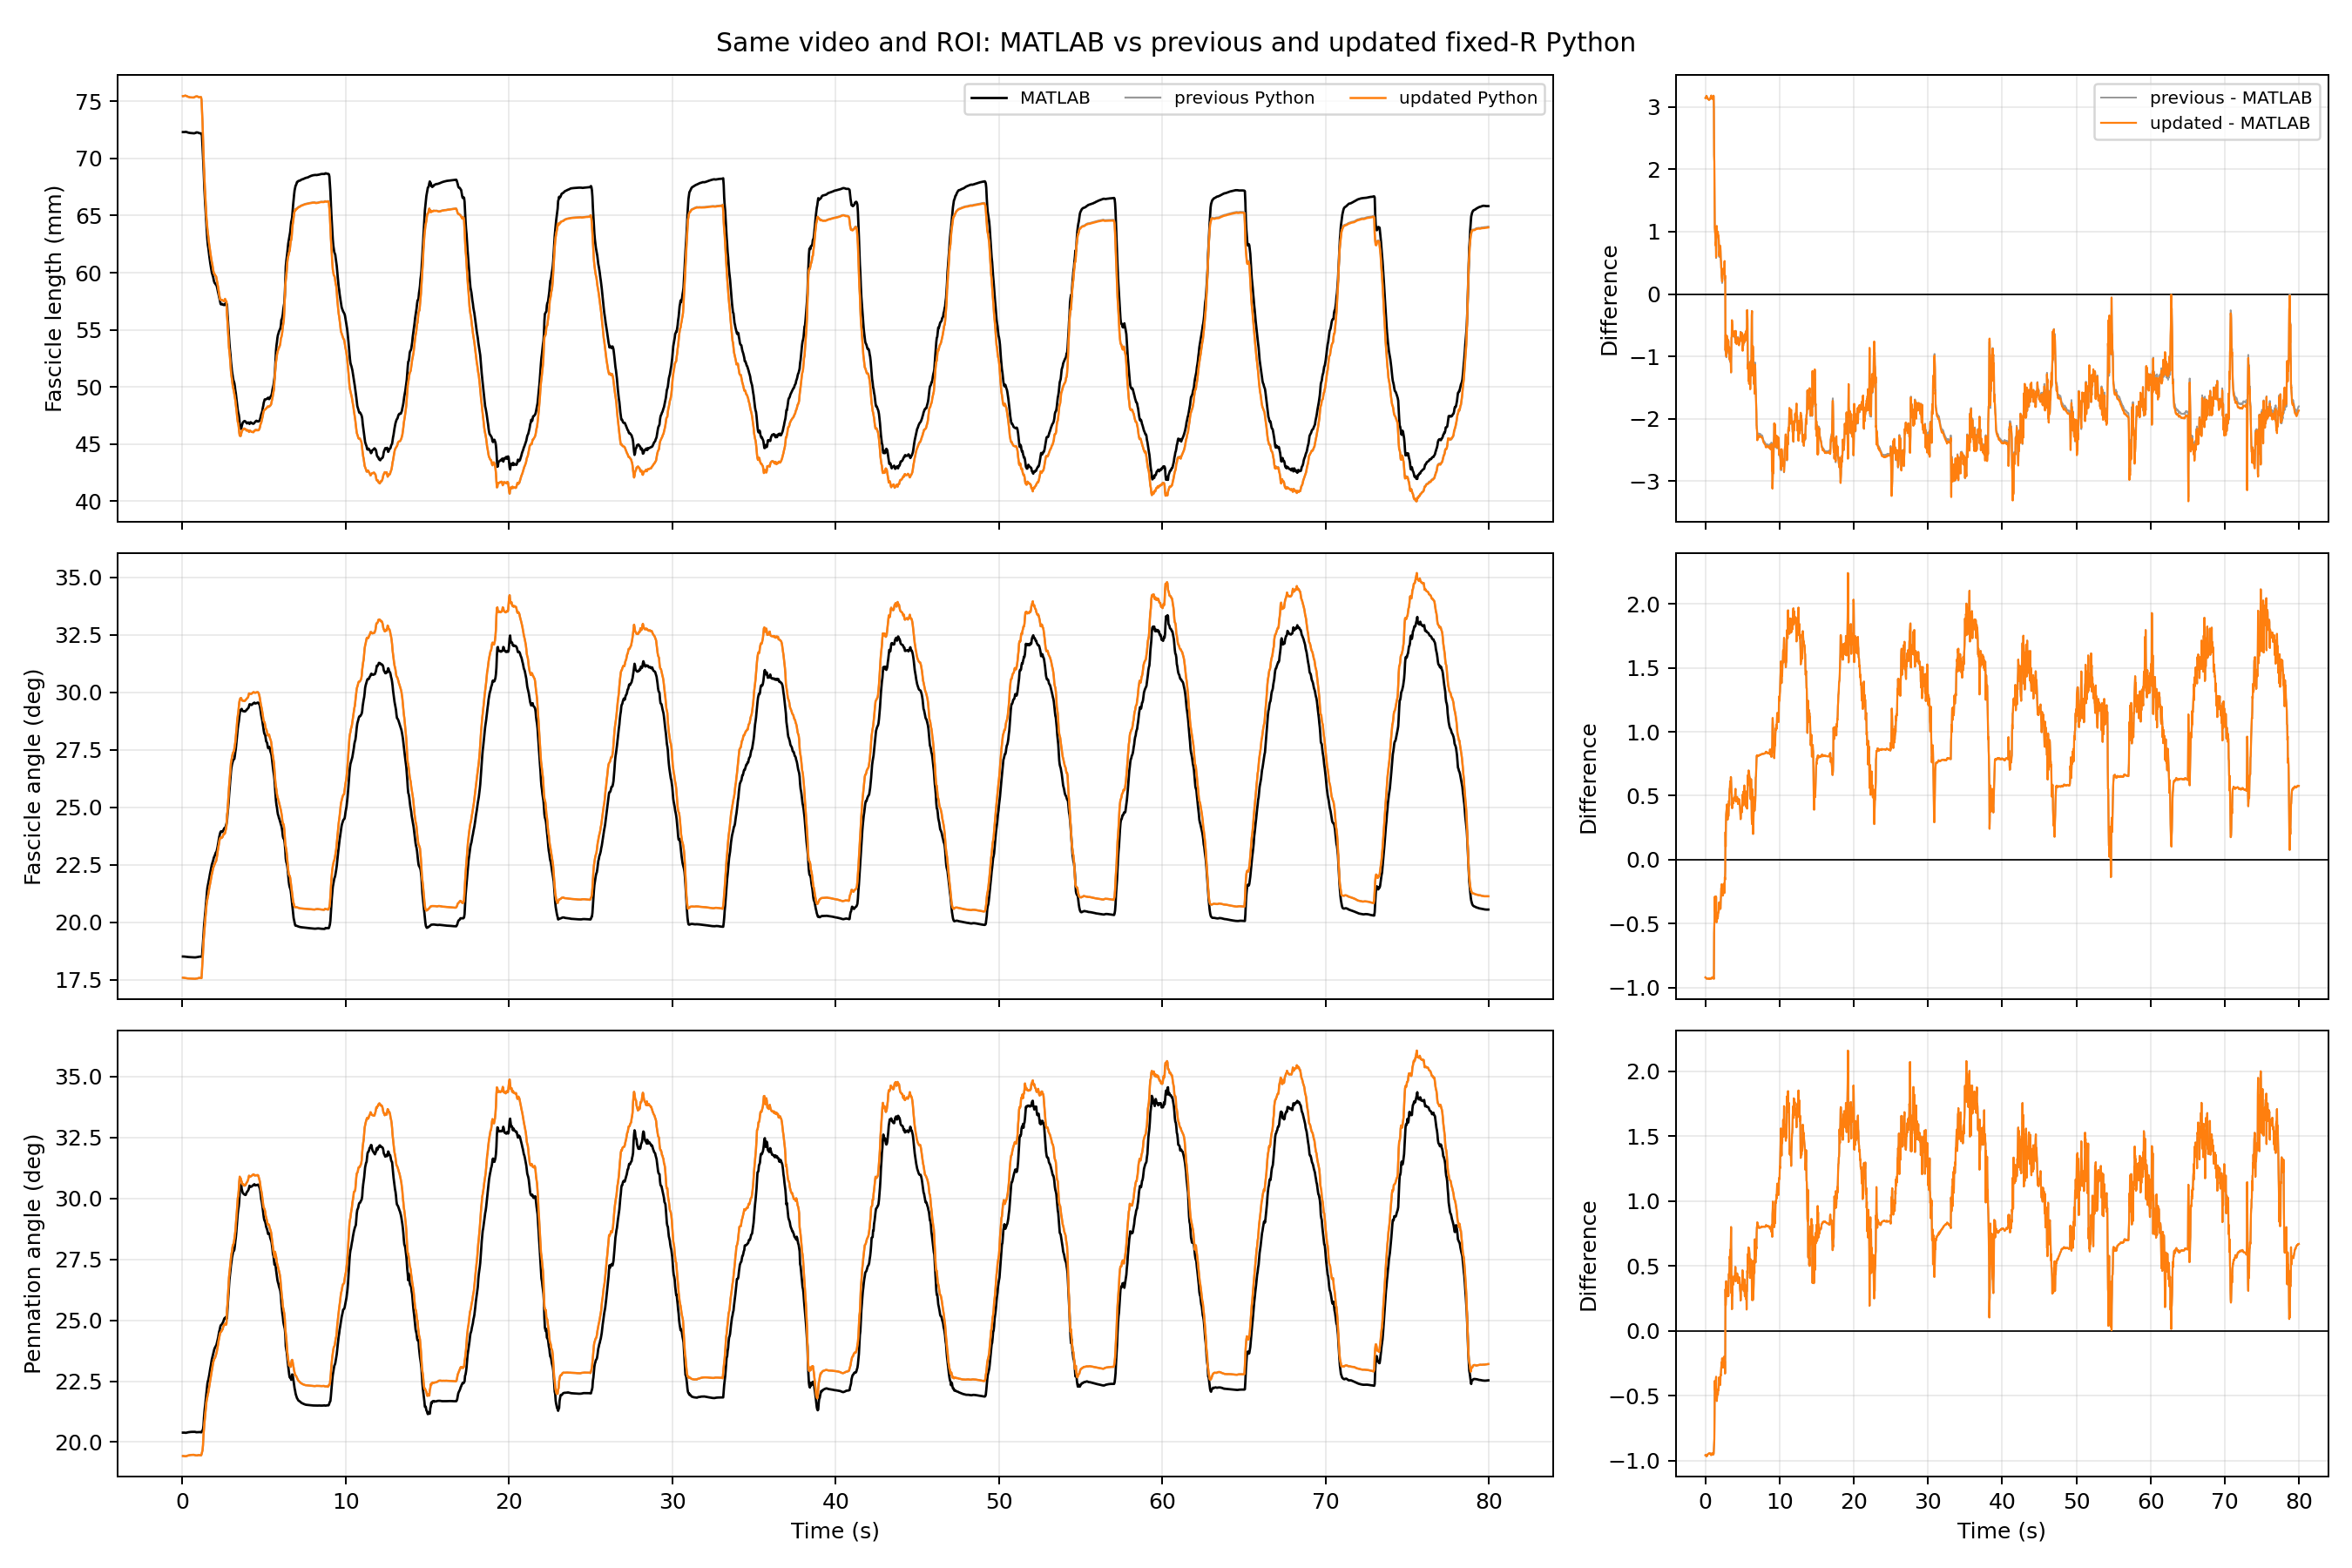

## Internal-state comparison

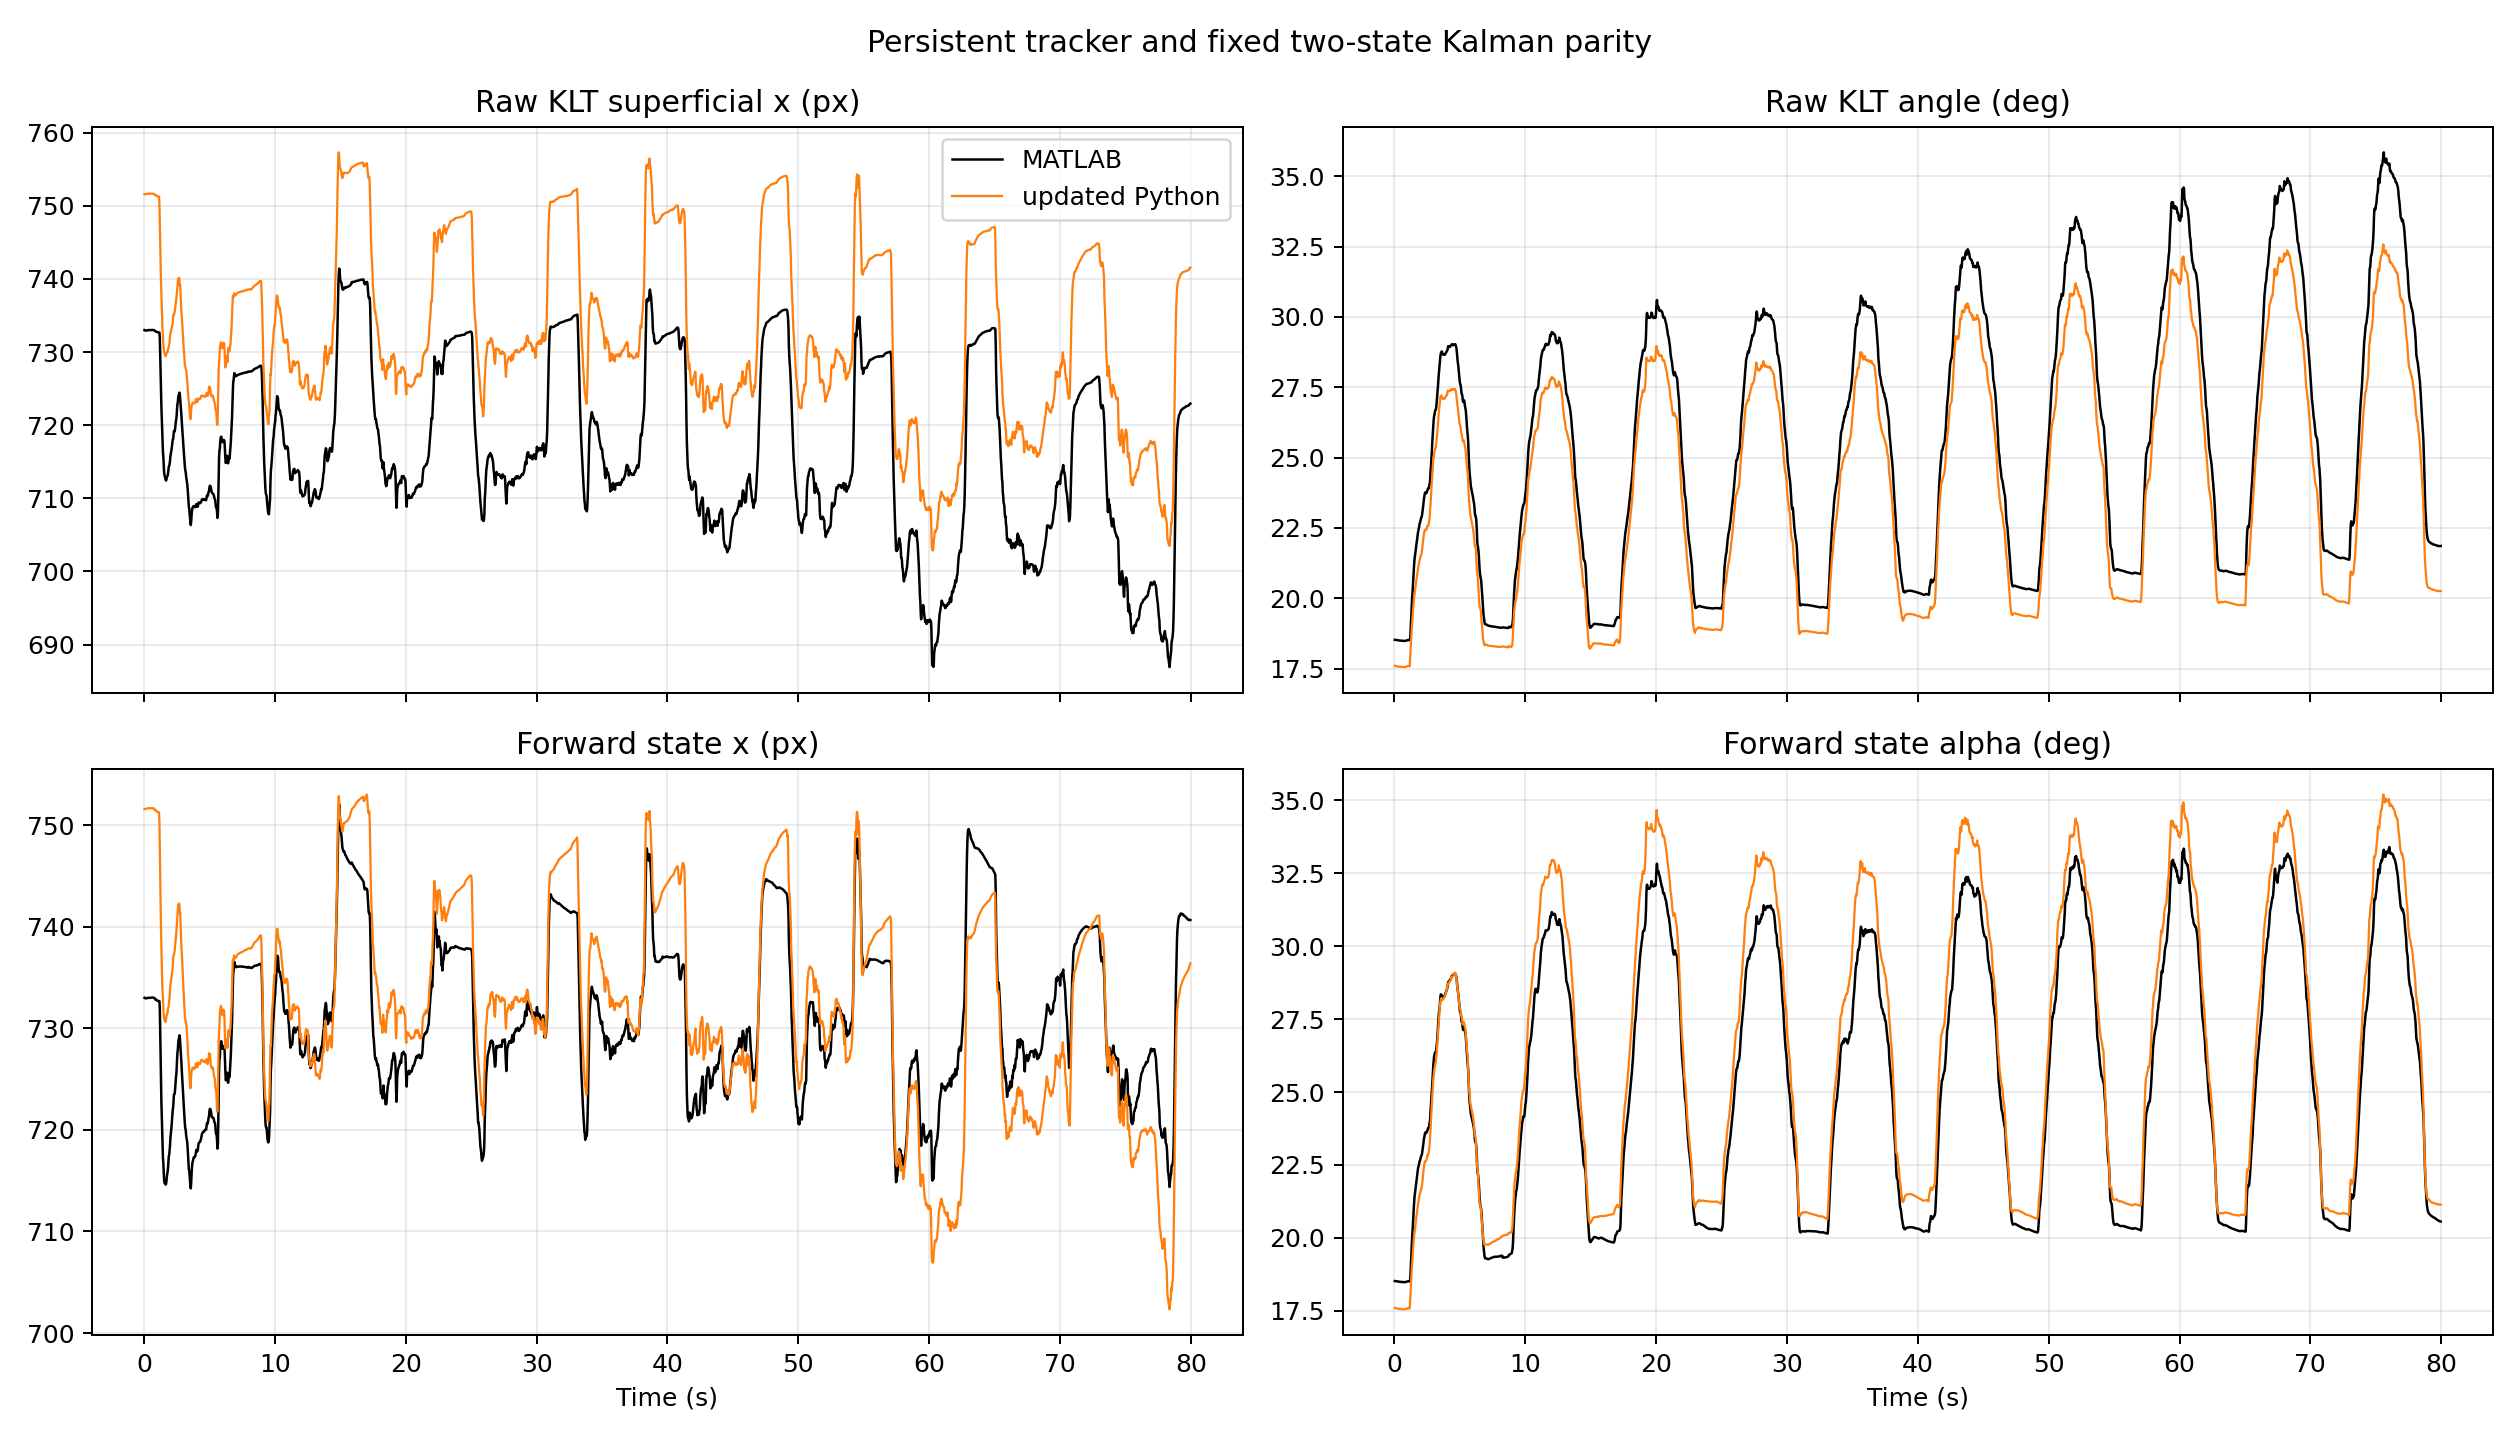

In [5]:
display(Markdown('## Final-output comparison'))
display(Image(filename=str(OUT / 'matlab_python_before_after.png')))

display(Markdown('## Internal-state comparison'))
display(Image(filename=str(OUT / 'tracker_kalman_state_comparison.png')))